In [12]:
import sys, os
sys.path.append(os.path.abspath(".."))

import torch
import matplotlib.pyplot as plt

from src.models.vae import VAE

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)
model.load_state_dict(torch.load("../experiments/vae_mnist.pth", map_location=device))
model.eval()

VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=2, bias=True)
  (fc3): Linear(in_features=2, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
)

In [14]:
import os
print("Notebook is running from:", os.getcwd())
print("Files in experiments/:", os.listdir("../experiments") if os.path.exists("../experiments") else "path not found")

Notebook is running from: /home/tajbid/deeplearning-dl2/notebooks
Files in experiments/: ['.gitkeep', 'vae_mnist.pth']


In [15]:
from src.data.mnist import test_loader

# Grab one batch of real test images 
images, _ = next(iter(test_loader))
images = images.to(device)

# Reconstruct them (no gradient needed we are just looking)
with torch.no_grad():
    x_recon, mu, logvar = model(images)

# Reshape the reconstructions back to 28x28 images
x_recon = x_recon.view(-1, 1, 28, 28)

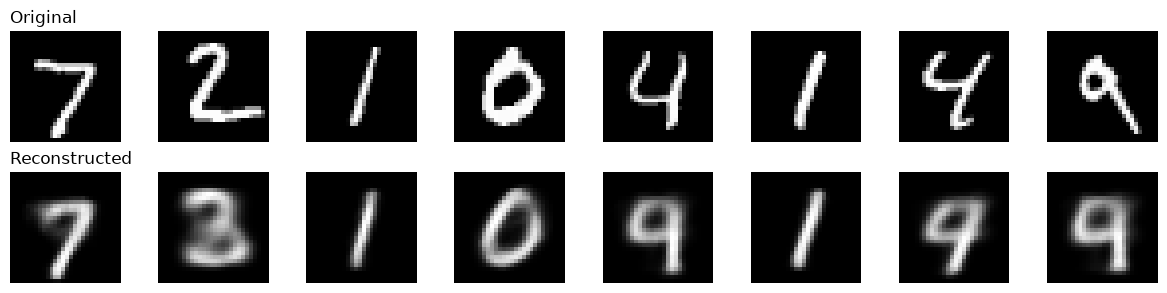

In [16]:
n = 8  # how many digits to show

fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
for i in range(n):
    # Top row: original
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap="gray")
    axes[0, i].axis("off")
    # Bottom row: reconstruction
    axes[1, i].imshow(x_recon[i].cpu().squeeze(), cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_title("Original", loc="left")
axes[1, 0].set_title("Reconstructed", loc="left")
plt.tight_layout()
plt.savefig("../assets/reconstructions.png", dpi=150, bbox_inches="tight")
plt.show()

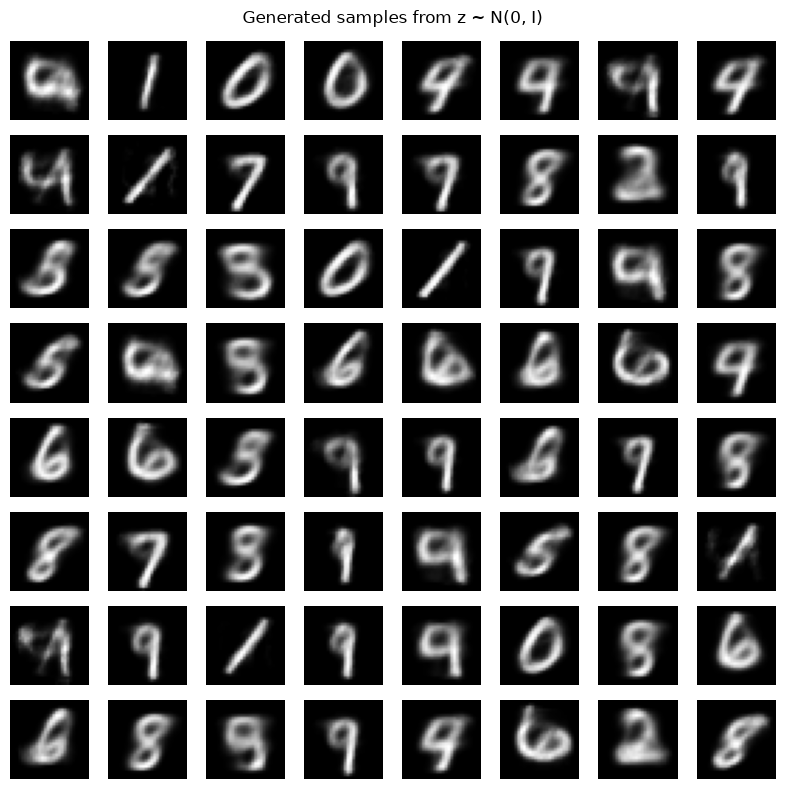

In [17]:
with torch.no_grad():
    # Sample random latent codes from the prior N(0, I)
    z = torch.randn(64, model.latent_dim).to(device)
    samples = model.decode(z).view(-1, 1, 28, 28)

# Plot in an 8x8 grid
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i].cpu().squeeze(), cmap="gray")
    ax.axis("off")
plt.suptitle("Generated samples from z ~ N(0, I)")
plt.tight_layout()
plt.savefig("../assets/samples.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
%pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 4.5 MB/s  0:00:07 eta 0:00:010:00:01
Note: you may need to restart the kernel to use updated packages.


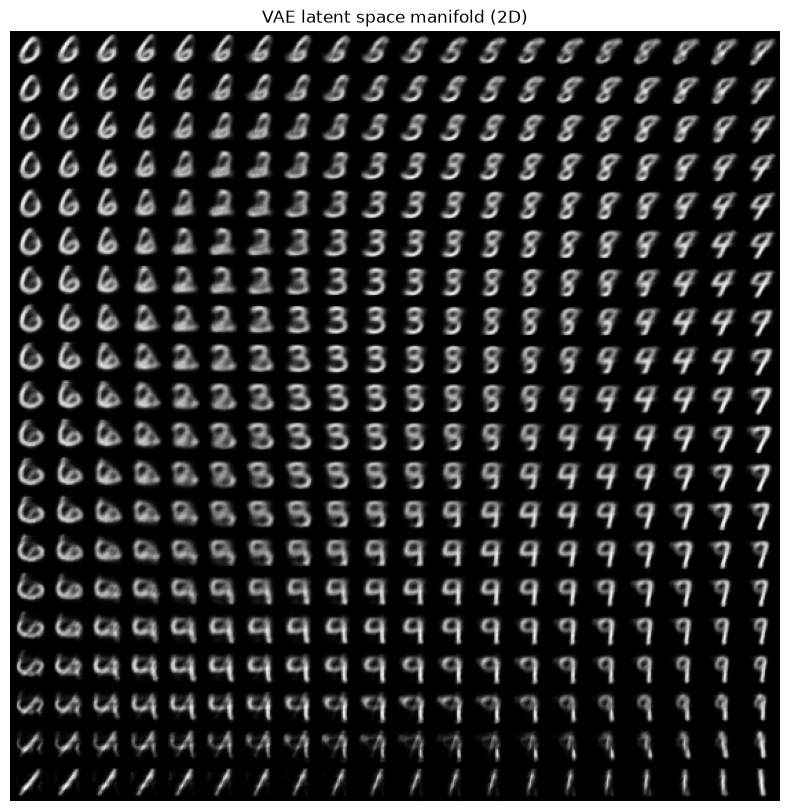

In [18]:
import numpy as np
from scipy.stats import norm

n = 20                    # 20x20 grid of digits
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

# Sweep a grid over the latent plane, spaced by the normal quantiles
grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
grid_y = norm.ppf(np.linspace(0.05, 0.95, n))

with torch.no_grad():
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            digit = model.decode(z).view(digit_size, digit_size).cpu().numpy()
            figure[i * digit_size:(i + 1) * digit_size,
                   j * digit_size:(j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="gray")
plt.title("VAE latent space manifold (2D)")
plt.axis("off")
plt.savefig("../assets/latent_manifold.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
import os
print(os.listdir("../assets"))

['reconstructions.png', 'latent_manifold.png', 'samples.png']
